# Linear Regression


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [3]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)

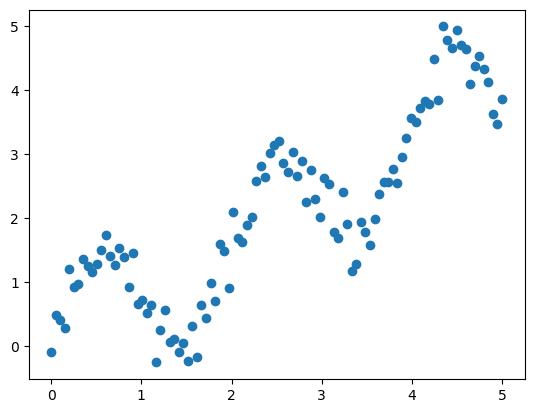

In [4]:
plt.scatter(x,y)

#### nonlinear

In [5]:
regr_lin = LinearRegression()

In [6]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [7]:
regr_lin.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


0.5867194875332927


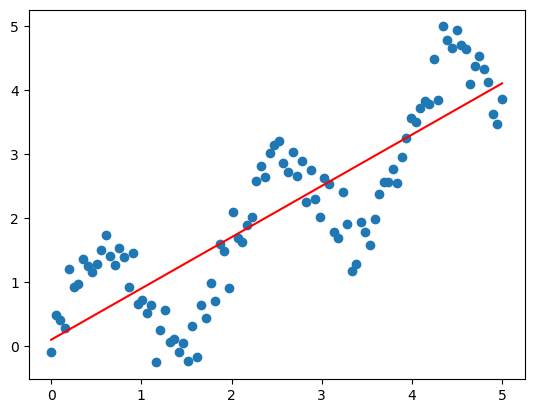

In [8]:
Y=regr_lin.predict(X)
plt.scatter(x,y)
plt.plot(x,Y , color='r')
mse = np.sum((Y-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [11]:
print(x.shape)

(100,)


In [15]:
print(x.shape)
print(X.shape)
X_poly = np.array([[k, k**2, k**3, k**4, k**5, k**6] for k in x])  # add k**6 to try it (二維振烈、變成多項式 有6個X)
print(X_poly.shape)
print(X_poly)
X_poly

(100,)
(100, 1)
(100, 6)
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [5.05050505e-02 2.55076013e-03 1.28826269e-04 6.50637722e-06
  3.28604910e-07 1.65962076e-08]
 [1.01010101e-01 1.02030405e-02 1.03061015e-03 1.04102036e-04
  1.05153571e-05 1.06215729e-06]
 [1.51515152e-01 2.29568411e-02 3.47830926e-03 5.27016555e-04
  7.98509932e-05 1.20986353e-05]
 [2.02020202e-01 4.08121620e-02 8.24488122e-03 1.66563257e-03
  3.36491428e-04 6.79780663e-05]
 [2.52525253e-01 6.37690032e-02 1.61032836e-02 4.06648576e-03
  1.02689034e-03 2.59315744e-04]
 [3.03030303e-01 9.18273646e-02 2.78264741e-02 8.43226488e-03
  2.55523178e-03 7.74312661e-04]
 [3.53535354e-01 1.24987246e-01 4.41874103e-02 1.56218117e-02
  5.52286273e-03 1.95252723e-03]
 [4.04040404e-01 1.63248648e-01 6.59590497e-02 2.66501211e-02
  1.07677257e-02 4.35059624e-03]
 [4.54545455e-01 2.06611570e-01 9.39143501e-02 4.26883410e-02
  1.94037913e-02 8.81990516e-03]
 [5.05050505e-01 2.550760

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [5.05050505e-02, 2.55076013e-03, 1.28826269e-04, 6.50637722e-06,
        3.28604910e-07, 1.65962076e-08],
       [1.01010101e-01, 1.02030405e-02, 1.03061015e-03, 1.04102036e-04,
        1.05153571e-05, 1.06215729e-06],
       [1.51515152e-01, 2.29568411e-02, 3.47830926e-03, 5.27016555e-04,
        7.98509932e-05, 1.20986353e-05],
       [2.02020202e-01, 4.08121620e-02, 8.24488122e-03, 1.66563257e-03,
        3.36491428e-04, 6.79780663e-05],
       [2.52525253e-01, 6.37690032e-02, 1.61032836e-02, 4.06648576e-03,
        1.02689034e-03, 2.59315744e-04],
       [3.03030303e-01, 9.18273646e-02, 2.78264741e-02, 8.43226488e-03,
        2.55523178e-03, 7.74312661e-04],
       [3.53535354e-01, 1.24987246e-01, 4.41874103e-02, 1.56218117e-02,
        5.52286273e-03, 1.95252723e-03],
       [4.04040404e-01, 1.63248648e-01, 6.59590497e-02, 2.66501211e-02,
        1.07677257e-02, 

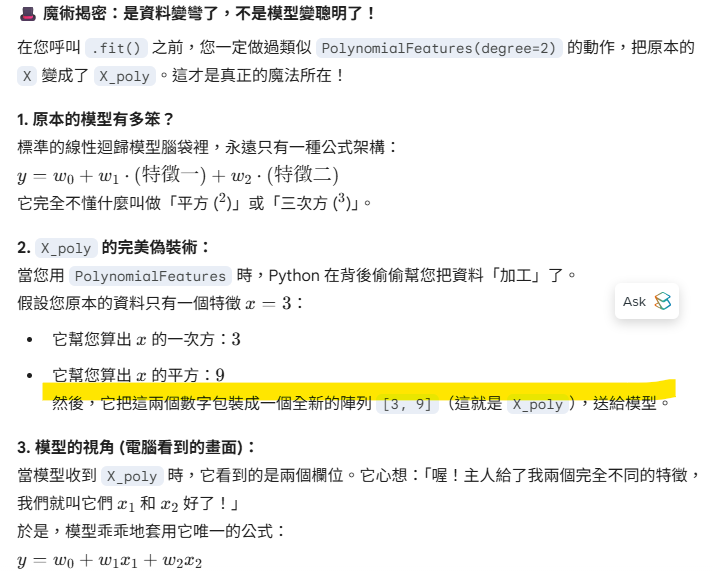

In [13]:
regr_poly = LinearRegression()

In [14]:
regr_poly.fit(X_poly, y)

LinearRegression()

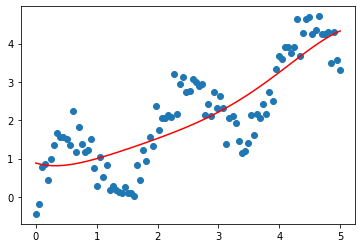

In [15]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')

In [16]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-0.47610227  0.9294618  -0.42798929  0.09698188 -0.00784717]
interception:  0.8828562606329244


In [10]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b #矩陣鄉城前要先轉至

NameError: name 'regr_poly' is not defined

#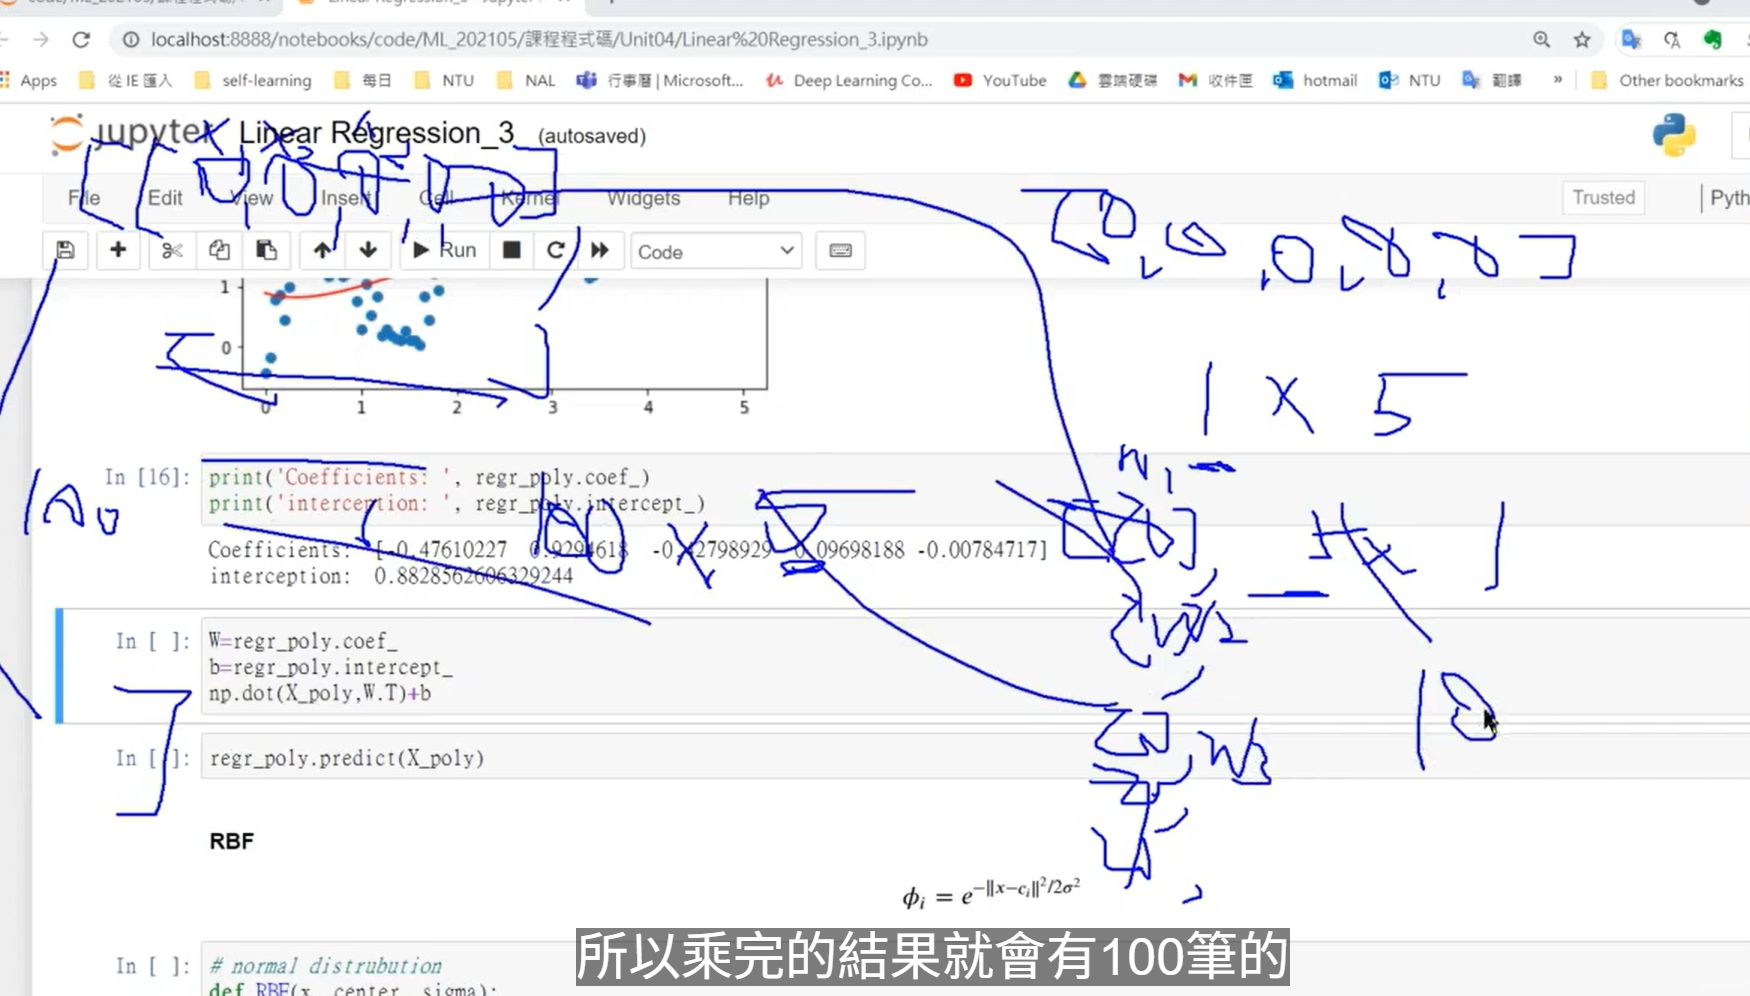

In [11]:
regr_poly.predict(X_poly)

NameError: name 'regr_poly' is not defined

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [19]:
# normal distrubution (是已經先假設這個函數可以fit! 而不適用ML自己去找出的model
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [20]:
sigma = 0.3

In [21]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])



In [22]:
regr_rbf = LinearRegression()

In [23]:
regr_rbf.fit(X_rbf, y)

LinearRegression()

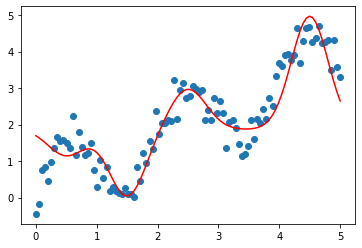

In [24]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')

In [25]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.72620466 -1.83462409  1.09615001 -0.01194894  3.09093005]
interception:  1.877906975572715


#### Comparison

In [26]:
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

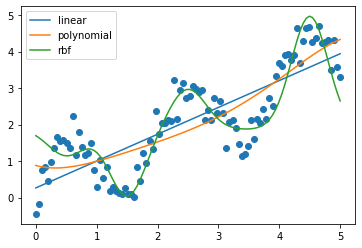

In [27]:
plt.scatter(x,y)

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()

## 請計算模型的MSE

In [28]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.6099512206136817


In [29]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.5531666918302569


In [30]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.28356996943295043
